# 実行例4.4 ピマ族データを用いた識別（p.49 図4.8,p.50 図4.9）

In [14]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using DataFrames
using CairoMakie

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


## Ⅰ　学習データの散布図

### 1. 学習データの読み込み

In [15]:
# (1)pima.tr.csvのファイルパスを設定する
filepath = joinpath(@__DIR__, "Pima.tr.csv")

# (2)pima.tr.csv（filepath）を読み出す
lines = open(filepath, "r") do io
    Iterators.drop(eachline(io), 1) |> collect
end

# (3)データ配列の準備
glu_tr = Int64[]
bmi_tr = Float64[]
type_tr = Bool[]

# (4)読み出した行をカンマ区切りのデータ配列にする
for line in lines
    rownames, npreg, glu, bp, skin, bmi, ped, age, type = split(line, ",")
    push!(glu_tr,  parse(Int64, glu))
    push!(bmi_tr,  parse(Float64, bmi))
    push!(type_tr, strip(type)=="Yes")  # Yesの時に真を設定
end

### 2. 学習データのプロット

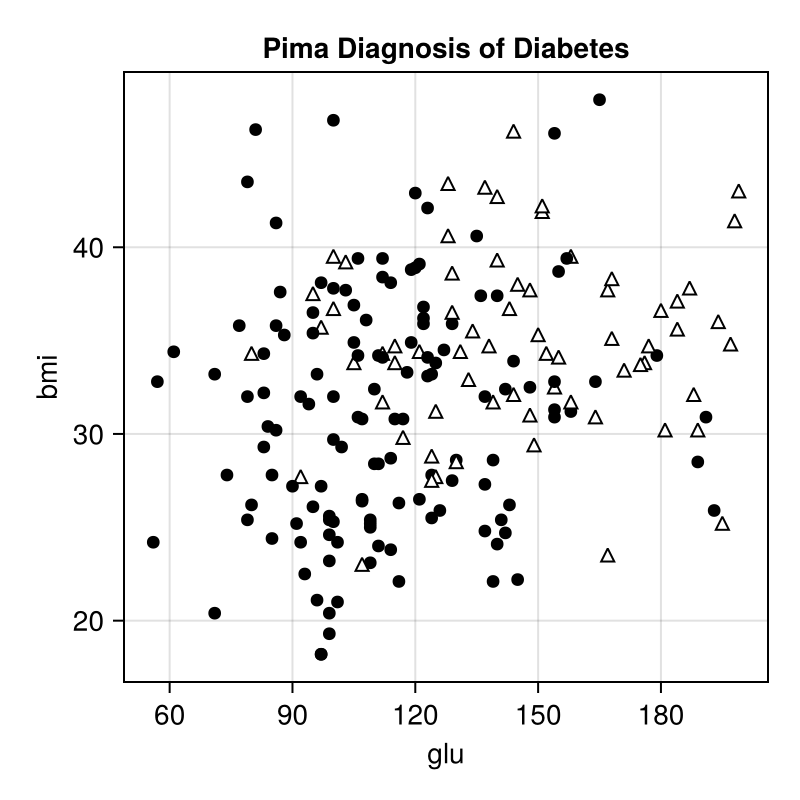

In [16]:
# (1)色とマークを指定するデータと同じ長さの配列を準備
colors  = [t ? :white : :black  for t in type_tr]
markers = [t ? :utriangle : :circle for t in type_tr]
strokecolors = [t ? :black : :transparent for t in type_tr]

# (2)グルコース濃度とBMIの散布図を描く
fig = Figure(size=(400, 400))
ax = Axis(fig[1, 1], xlabel="glu", ylabel="bmi", title="Pima Diagnosis of Diabetes")
scatter!(ax, glu_tr, bmi_tr, color=colors, marker=markers, strokecolor=strokecolors, strokewidth=1.0)

# (3)グラフの保存と表示
save("pima_scatter.png", fig)
fig

- 真偽判定の変数としてコード補完では`type`が出てくるがJuliaの型関連処理と衝突する恐れがあるので`t`に留めておいたほうが賢明。

## Ⅱ　識別境界の計算
- クラスC_noとクラスC_yesに識別する。

### 1. 学習データ数（サンプル数）の確認

In [17]:
# (1)学習データ数の確認
num_samples = length(lines)

# (2)各クラスのサンプル数の確認
num_no = length(filter(t -> t == false, type_tr))  # Noのサンプル数
num_yes = length(filter(t -> t == true, type_tr))   # Yesのサンプ数

68

### 2. 平均ベクトルの計算

In [18]:
# (1)平均ベクトルの計算
μ_no = [mean(glu_tr[type_tr .== false]); mean(bmi_tr[type_tr .== false])]
μ_yes = [mean(glu_tr[type_tr .== true]); mean(bmi_tr[type_tr .== true])]

2-element Vector{Float64}:
 145.05882352941177
  34.70882352941176

- VSCodeのコード補完に従って下記コードにすると、type_trの真偽を見ていないので[NaN, NaN]が返ってくる。
```
μ_no = [mean(filter(t -> t == false, glu_tr)); mean(filter(t -> t == false, bmi_tr))]
μ_yes = [mean(filter(t -> t == true, glu_tr)); mean(filter(t -> t == true, bmi_tr))]
```

### 3. クラスごとの共分散行列の計算
- ここでは`cov()`を使わず、p.37の方法で共分散行列を求める。
- 共分散を取る場合、分母をN-1にすると（ベッセルの補正）Juliaの`cov()`の結果と揃う。「普遍共分散」という考え方。
- -1を取らない「標本共分散/最大尤度推定」という考え方もある。

In [19]:
# (1)データ抽出
# 2行num_no/yes列の行列
data_no = [glu_tr[type_tr .== false]'; bmi_tr[type_tr .== false]']
data_yes = [glu_tr[type_tr .== true]'; bmi_tr[type_tr .== true]']

# (2)発症しなかった人（no : type_trがfalse）の人の共分散行列
# glu_trの抽出
glu_no = glu_tr[type_tr .== false]
# glu_trの平均と分散
μ_glu_no = mean(glu_no)
var_glu_no = var(glu_no)
# bmi_trの抽出
bmi_no = bmi_tr[type_tr .== false]
# bmi_trの平均と分散
μ_bmi_no = mean(bmi_no)
var_bmi_no = var(bmi_no)
# glu_noとbmi_noの共分散
cov_no = sum((glu_no .- μ_glu_no) .* (bmi_no .- μ_bmi_no)) / (num_no - 1)
# 共分散行列
Σ_no = [var_glu_no cov_no; 
    cov_no var_bmi_no]
# 平均ベクトル
μ_no = [μ_glu_no; μ_bmi_no]

# (3)発症した人（yes : type_trがtrue）の人の共分散行列
# glu_trの抽出
glu_yes = glu_tr[type_tr .== true]
# glu_trの平均と分散
μ_glu_yes = mean(glu_yes)
var_glu_yes = var(glu_yes)
# bmi_trの抽出
bmi_yes = bmi_tr[type_tr .== true]
# bmi_trの平均と分散
μ_bmi_yes = mean(bmi_yes)
var_bmi_yes = var(bmi_yes)
# glu_yesとbmi_yesの共分散
cov_yes = sum((glu_yes .- μ_glu_yes) .* (bmi_yes .- μ_bmi_yes)) / (num_yes - 1)
# 共分散行列
Σ_yes = [var_glu_yes cov_yes; 
    cov_yes var_bmi_yes]
# 平均ベクトル
μ_yes = [μ_glu_yes; μ_bmi_yes]

2-element Vector{Float64}:
 145.05882352941177
  34.70882352941176

### 4. クラスごとの事前確率

In [20]:
# (1)クラスごとの事前確率
# クラスC_noの事前確率
P_C_no = num_no / num_samples
# クラスC_yesの事前確率
P_C_yes = num_yes / num_samples

0.34

### 5. 識別境界
- p.48 式4.32
$$
\begin{split}
f_{ij}(x) &= g_i(x) - g_j(x) \\
&= (x - \mu_i)^T \Sigma_i^{-1} (x - \mu_i) + \ln|\Sigma_i| - 2\ln P(C_i) \\
&\quad - (x - \mu_j)^T \Sigma_j^{-1} (x - \mu_j) - \ln|\Sigma_j| + 2\ln P(C_j) \\
&= \underbrace{x^T (\Sigma_i^{-1} - \Sigma_j^{-1}) x}_{\text{行列}S} 
+ \underbrace{2(\mu_j^T \Sigma_j^{-1} - \mu_i^T \Sigma_i^{-1}) x
}_{\text{ベクトル}c^T} \\
&\quad + \underbrace{\mu_i^T \Sigma_i^{-1} \mu_i - \mu_j^T \Sigma_j^{-1} \mu_j + \ln (\frac{|\Sigma_i|}{|\Sigma_j|}) - 2\ln (\frac{P(C_i)}{P(C_j)})}_{\text{スカラー}F} \\
&= x^T S x + 2 c^T x + F = 0
\end{split}
$$

In [21]:
# (1)識別関数
function f_ij(x, S, c_T, F)
    f_decisionboundary = transpose(x) * S * x + 2 * c_T * x + F
    return f_decisionboundary[1]  # 行列演算の結果は1×1行列になるので[1]でスカラーとして返す
end

f_ij (generic function with 1 method)

### 6. 2次識別境界の計算

In [22]:
# (1)識別関数のパラメーター
# 行列S
S_quadratic = inv(Σ_no) - inv(Σ_yes)

# ベクトルc^T
c_T_quadratic = (transpose(μ_yes) * inv(Σ_yes)) - (transpose(μ_no) * inv(Σ_no))

# スカラーF
F_quadratic = (transpose(μ_no) * inv(Σ_no) * μ_no) - (transpose(μ_yes) * inv(Σ_yes) * μ_yes) + (logdet(Σ_no) - logdet(Σ_yes)) - 2 * log(P_C_no / P_C_yes)

# (2)識別境界を描画するためのグリッドを作成
glu_grid = range(50, 200, length=100)
bmi_grid = range(15.0, 50.0, length=100)

# (3) グリッド全体に対して識別境界関数f_ijを適用して高さの行列z_quadraticを計算
z_quadratic = [f_ij([glu, bmi], S_quadratic, c_T_quadratic, F_quadratic) for glu in glu_grid, bmi in bmi_grid]

100×100 Matrix{Float64}:
 -15.3401   -15.0224   -14.7094   -14.401    …  -6.10817  -6.24013  -6.37672
 -15.2893   -14.9718   -14.659    -14.3508      -6.07707  -6.20923  -6.34603
 -15.237    -14.9198   -14.6071   -14.2991      -6.04451  -6.17687  -6.31387
 -15.1833   -14.8662   -14.5538   -14.246       -6.01048  -6.14304  -6.28024
 -15.1281   -14.8112   -14.499    -14.1914      -5.97498  -6.10775  -6.24515
 -15.0714   -14.7548   -14.4427   -14.1354   …  -5.93801  -6.07098  -6.20859
 -15.0133   -14.6968   -14.385    -14.0778      -5.89957  -6.03275  -6.17056
 -14.9537   -14.6374   -14.3258   -14.0188      -5.85967  -5.99305  -6.13106
 -14.8926   -14.5766   -14.2651   -13.9584      -5.81829  -5.95188  -6.09009
 -14.8301   -14.5142   -14.203    -13.8964      -5.77545  -5.90924  -6.04766
   ⋮                                         ⋱                      
  -4.7057    -4.40651   -4.11196   -3.82205      2.73317   2.58273   2.42765
  -4.52131   -4.22233   -3.92798   -3.63827      2.89786   

- 行列式の対数はlogdet()で求めることができる（行列式の計算は数値的に不安定な場合があるため、対数を取ることで安定化させる）。

### 7. 2次式別境界の描画
- 図4.9(a) 2次識別関数の等高線

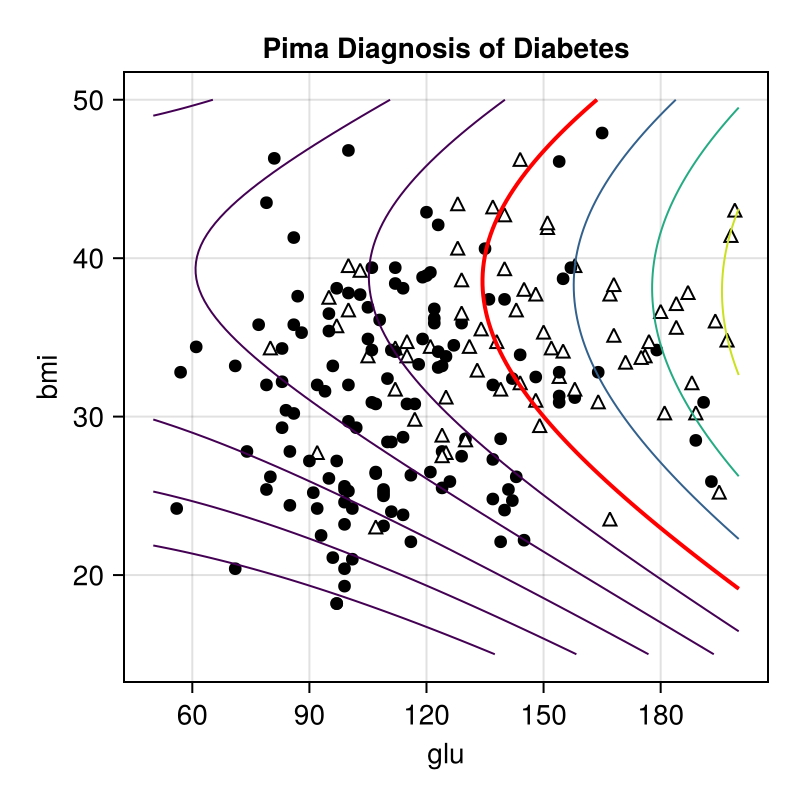

In [23]:
# (1)学習データ散布図の再プロット
empty!(fig)
ax_quadratic = Axis(fig[1, 1], xlabel="glu", ylabel="bmi", title="Pima Diagnosis of Diabetes")
scatter!(ax_quadratic, glu_tr, bmi_tr, color=colors, marker=markers, strokecolor=strokecolors, strokewidth=1.0)

# (2)等高線の描画
# 等高線の間隔を-10から6まで2刻みにする
contour_levels = -10.0:2.0:6.0

# 等高線の描画
contour!(ax_quadratic, glu_grid, bmi_grid, z_quadratic,
    levels=contour_levels,
    colormap=:viridis,
    colorrange=(0,maximum(z_quadratic)))

# (3)識別境界の描画
contour!(ax_quadratic, glu_grid, bmi_grid, z_quadratic,
    levels=[0.0],
    color=:red,
    linewidth=2)

# (3)グラフの保存と描画
save("pima_scatter.png", fig)
fig

### 8. 線形識別境界の計算
- 2つのクラスの共分散行列が等しいものとするため共通の共分散行列を下記で求めている（p.50 式4.37）。
$$
\Sigma_{pool} = \frac{N_1}{N} \Sigma_1 + \frac{N_2}{N} \Sigma_2 = \frac{1}{N} (S_1 + S_2)
$$

In [24]:
# (1) クラス共通の共分散の計算
Σ_pool = (num_no * Σ_no + num_yes * Σ_yes) / num_samples

# (2) 線形識別関数のパラメーターの計算
# 行列S
S_linear = inv(Σ_pool) - inv(Σ_pool)  # 共通の共分散を使うのでSはゼロ行列になる

# ベクトルc^T
c_T_linear = (transpose(μ_yes) * inv(Σ_pool)) - (transpose(μ_no) * inv(Σ_pool))

# スカラーF
F_linear = (transpose(μ_no) * inv(Σ_pool) * μ_no) - (transpose(μ_yes) * inv(Σ_pool) * μ_yes) + (logdet(Σ_pool) - logdet(Σ_pool)) - 2 * log(P_C_no / P_C_yes)    # 共通の共分散を使うので行列式の差はゼロになる

# (2)識別境界を描画するためのグリッドを作成
glu_grid = range(50, 200, length=100)
bmi_grid = range(15.0, 50.0, length=100)

# (3) グリッド全体に対して識別境界関数f_ijを適用して高さの行列z_linearを計算
z_linear = [f_ij([glu, bmi], S_linear, c_T_linear, F_linear) for glu in glu_grid, bmi in bmi_grid]

100×100 Matrix{Float64}:
 -10.6477    -10.5865    -10.5254    …  -4.71326  -4.65208  -4.5909
 -10.5285    -10.4673    -10.4061       -4.594    -4.53281  -4.47163
 -10.4092    -10.348     -10.2868       -4.47473  -4.41355  -4.35237
 -10.2899    -10.2288    -10.1676       -4.35546  -4.29428  -4.2331
 -10.1707    -10.1095    -10.0483       -4.2362   -4.17502  -4.11384
 -10.0514     -9.99022    -9.92904   …  -4.11693  -4.05575  -3.99457
  -9.93214    -9.87096    -9.80978      -3.99767  -3.93649  -3.87531
  -9.81287    -9.75169    -9.69051      -3.8784   -3.81722  -3.75604
  -9.69361    -9.63243    -9.57125      -3.75914  -3.69796  -3.63678
  -9.57434    -9.51316    -9.45198      -3.63987  -3.57869  -3.51751
   ⋮                                 ⋱                      
   0.205393    0.266573    0.327753      6.13986   6.20104   6.26222
   0.324658    0.385838    0.447018      6.25913   6.32031   6.38149
   0.443923    0.505103    0.566283      6.37839   6.43957   6.50075
   0.563188    0.62

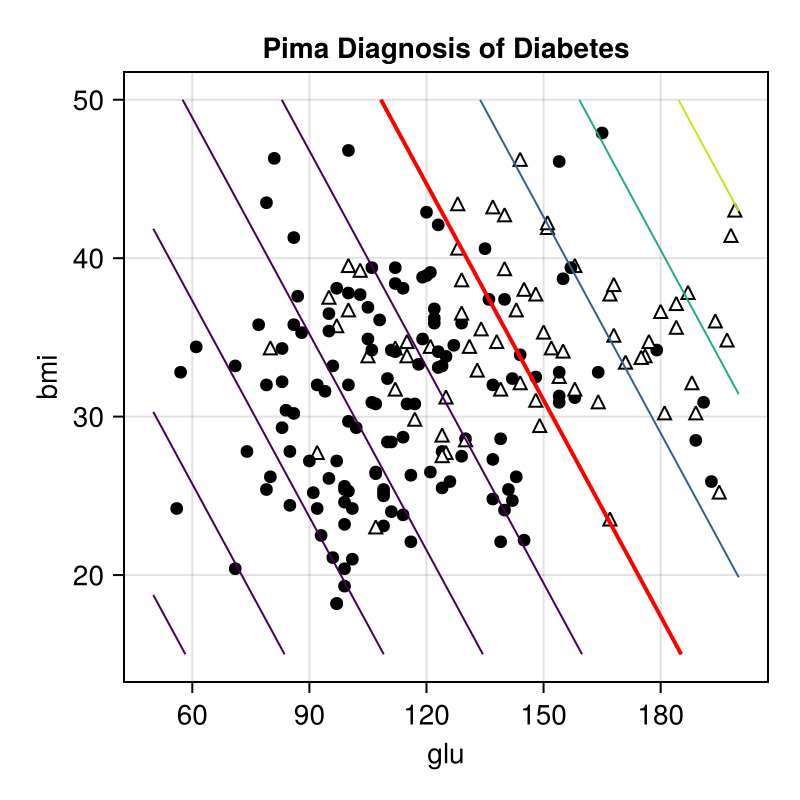

In [25]:
# (1)学習データ散布図の再プロット
empty!(fig)
ax_linear = Axis(fig[1, 1], xlabel="glu", ylabel="bmi", title="Pima Diagnosis of Diabetes")
scatter!(ax_linear, glu_tr, bmi_tr, color=colors, marker=markers, strokecolor=strokecolors, strokewidth=1.0)

# (2)等高線の描画
contour!(ax_linear, glu_grid, bmi_grid, z_linear,
    levels=contour_levels,
    colormap=:viridis,
    colorrange=(0,maximum(z_quadratic)))

# (3)識別境界の描画
contour!(ax_linear, glu_grid, bmi_grid, z_linear,
    levels=[0.0],
    color=:red,
    linewidth=2)

# (3)グラフの保存と描画
save("pima_scatter.png", fig)
fig

### 9. 2次識別境界と線形識別境界の並列表示
- p.50 図4.9

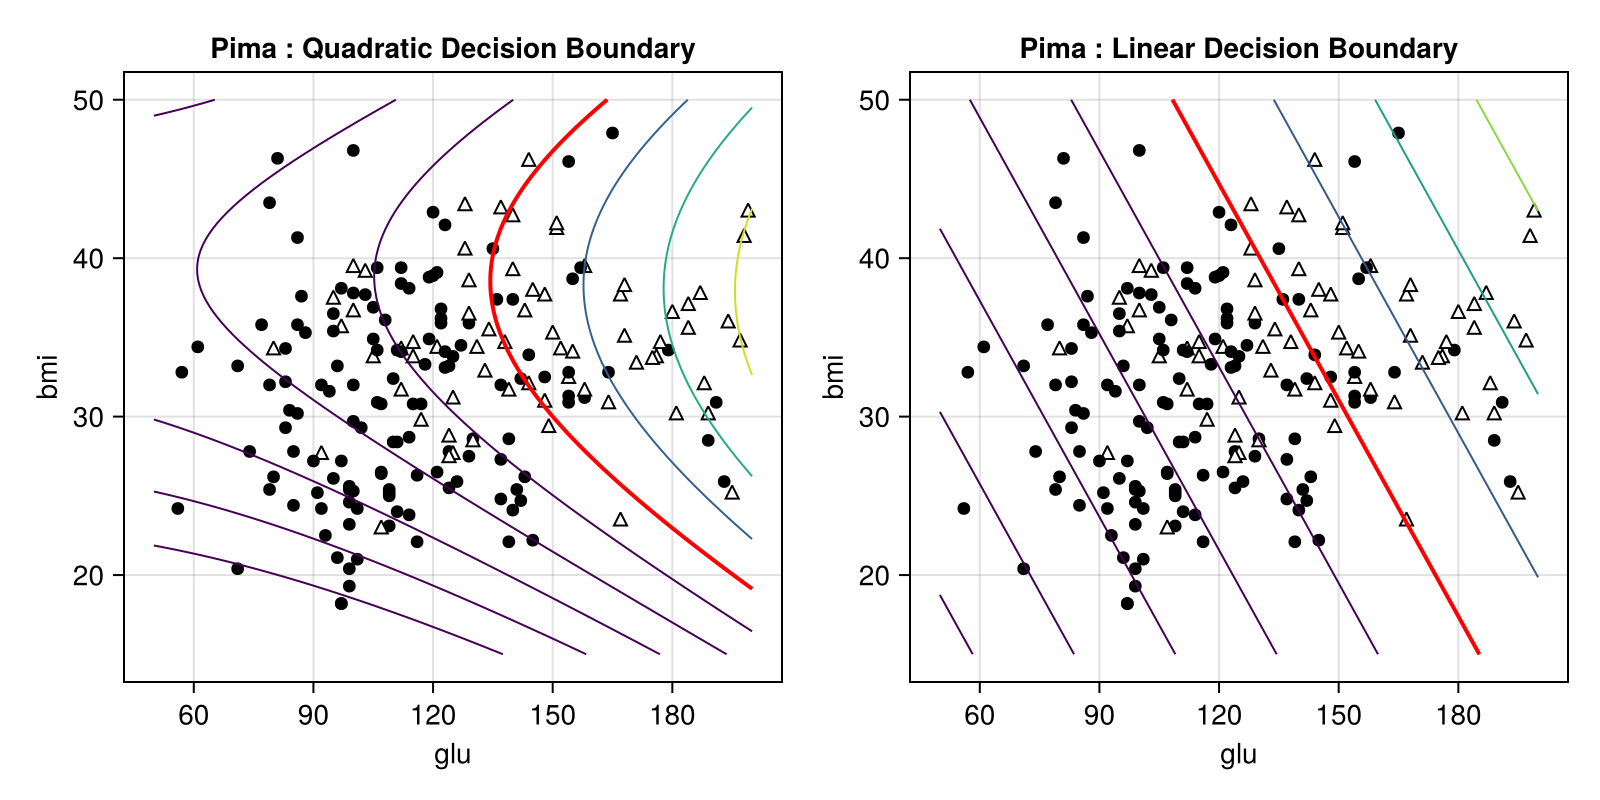

In [26]:
# (1)並列描画用キャンバスの準備
fig_double = Figure(size=(800, 400))

# (2)描画関数
function plot_recognition(ax_targeted, z_variable)
    scatter!(ax_targeted, glu_tr, bmi_tr, color=colors, marker=markers, strokecolor=strokecolors, strokewidth=1.0)
    
    # 等高線の間隔
    contour_levels = -10.0:2.0:6.0
    
    # 等高線の描画
    contour!(ax_targeted, glu_grid, bmi_grid, z_variable,
        levels=contour_levels,
        colormap=:viridis,
        colorrange=(0,maximum(z_variable)))

    # 識別境界の描画
    contour!(ax_targeted, glu_grid, bmi_grid, z_variable,
        levels=[0.0],
        color=:red,
        linewidth=2)

end

# (3)2次識別境界用の座標軸
ax_quadratic = Axis(fig_double[1, 1], xlabel="glu", ylabel="bmi", title="Pima : Quadratic Decision Boundary")


# (4)線形識別境界用の座標軸
ax_linear = Axis(fig_double[1, 2], xlabel="glu", ylabel="bmi", title="Pima : Linear Decision Boundary")


# (5)識別境界図の並列表示
plot_recognition(ax_quadratic, z_quadratic)
plot_recognition(ax_linear, z_linear)

# (6)グラフの保存と描画
save("pima_recognition.png", fig_double)
fig_double

## Ⅲ　ROC曲線
- 偽陽性率 $\epsilon_2$ と真陽性率 $1-\epsilon_1$ の関係をグラフ化
- 偽陽性率：真のクラスが $n^*$ で識別クラスが $p$ のデータ（偽陽性 $FP$）の全体比率 $FP/N$
- 真陽性率：真のクラスが $p^*$ で識別クラスも $p$ のデータ（真陽性 $TP$）の全体比率 $TP/N$

### 1. 偽陽性率と真陽性率の計算

In [ ]:
# (1)評価値計算関数
function g_c(x, μ, Σ, P_c)
    g_evaluation_value = transpose(x - μ) * inv(Σ) * (x - μ) + logdet(Σ) - 2 * log(P_c)
    return g_evaluation_value[1]
end

# (2)クラス分け関数
function bool_prediction(x, μ, Σ, P_c, f_lv)
    if g_c(x, μ, Σ, P_c) >= f_lv
        class_prediction = true
    else
        class_prediction = false
    end
    return class_prediction
end

# (3)真陽性/偽陽性判定関数
function bool_evaluate(x, μ, Σ, P_c, f_lv, tp, fn, fp, tn)
    label = type_tr(x)
    pred = bool_prediction(x, μ, Σ, P_c, f_lv)
    if label && pred
        tp += 1 # 糖尿病を糖尿病と判定（真陽性）
    elseif !label && !pred
        tn += 1 # 健康を健康と判定（真陰性）
    elseif !label && pred
        fp += 1 # 健康を糖尿病と判定（偽陽性）
    else
        fn += 1 # 糖尿病を健康と判定（偽陰性）
    end
    return tp, tn, fp, fn
end

# (4)真陽性率/偽陽性率判定関数
function roc_rates(tp, tn, fp, fn)
    # 真陽性率
    tpr = tp / (tp + fn)
    # 偽陽性率
    fpr = fp / (fp + tn)
    return tpr, fpr
end


roc_rates (generic function with 1 method)

### 2. ROC曲線

In [ ]:
# (1)識別関数値を変化させた場合のROC
#クラスC_noのμ、Σ、事前確率P_c
μ = μ_no
Σ = Σ_no
P_c = num_no / num_samples

# ROC用配列の準備
roc = Tuple{Float64, Float64}[]

# ROC計算（識別関数値を変化させる範囲は-9～+7）
for f_lv in  -9:0.05:7
    # 判定変数の初期化
    tp, tn, fp, fn = 0, 0, 0, 0
    # 学習データの判定
    for i in 1:num_samples
        x = [glu_tr[i]; bmi[i]] 
        tp, tn, fp, fn = bool_evaluate(x, μ, Σ, P_c, f_lv, tp, fn, fp, tn)
    end
    tpr, fpr = roc_rates(tp, tn, fp, fn)
    push!(roc, (fpr, tpr))
end